In [1]:
"""
GeoSDI Geothermal v2.0 — Data Exploration Notebook
===================================================
Eksplorasi pertama: node geothermal + batas administrasi Indonesia.
"""

import sys
from pathlib import Path

# Tambahkan root project ke path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

from src.shared.config import get_settings
from src.shared.logger import setup_logging, get_logger

# Setup logging
setup_logging()
log = get_logger(__name__)
settings = get_settings()

log.info("Notebook started", extra={"data_path": str(settings.data_raw_path)})

# Konfigurasi display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (14, 8)

print(f"📁 Data raw path : {settings.data_raw_path}")
print(f"📁 Logs path     : {settings.logs_path}")
print(f"🌏 Environment   : {settings.app_env}")

{"timestamp": "2026-10-03T18:11:55.047391+00:00", "level": "INFO", "module": "logger", "function": "setup_logging", "line": 147, "logger": "src.shared.logger", "message": "Logging initialized", "extra": {"name": "src.shared.logger", "levelname": "INFO", "levelno": 20, "pathname": "C:\\geosdi\\src\\shared\\logger.py", "filename": "logger.py", "module": "logger", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 147, "funcName": "setup_logging", "created": 1791051115.0473912, "msecs": 47.0, "relativeCreated": 350579.1015625, "thread": 24900, "threadName": "MainThread", "processName": "MainProcess", "process": 2284, "taskName": "Task-46", "env": "development", "level": "INFO", "format": "json"}}
{"timestamp": "2026-10-03T18:11:55.048392+00:00", "level": "INFO", "module": "1123359280", "function": "<module>", "line": 26, "logger": "__main__", "message": "Notebook started", "extra": {"name": "__main__", "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\muham\\AppDa

In [2]:
# Baca CSV node geothermal
nodes_path = settings.data_raw_path / "geothermal_nodes.csv"
nodes = pd.read_csv(nodes_path)

print(f"📊 Jumlah node: {len(nodes)}")
print(f"📋 Kolom: {list(nodes.columns)}")
print("\n🔍 Preview 5 baris pertama:")
nodes.head()

📊 Jumlah node: 6
📋 Kolom: ['id', 'nama', 'provinsi', 'status', 'latitude', 'longitude']

🔍 Preview 5 baris pertama:


,id,nama,provinsi,status,latitude,longitude
0,WKP001,Kamojang,Jawa Barat,Operasi,-7.141,107.806
1,WKP002,Dieng,Jawa Tengah,Operasi,-7.209,109.902
2,WKP003,Lahendong,Sulawesi Utara,Operasi,1.213,124.847
3,WKP004,Sarulla,Sumatera Utara,Operasi,2.034,99.132
4,WKP005,Rantau Dedap,Sumatera Selatan,Operasi,-4.306,103.897


In [3]:
print("=" * 60)
print("STRUKTUR DATA")
print("=" * 60)
nodes.info()

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
nodes.describe(include="all")

STRUKTUR DATA
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         6 non-null      str    
 1   nama       6 non-null      str    
 2   provinsi   6 non-null      str    
 3   status     6 non-null      str    
 4   latitude   6 non-null      float64
 5   longitude  6 non-null      float64
dtypes: float64(2), str(4)
memory usage: 420.0 bytes

STATISTIK DESKRIPTIF


,id,nama,provinsi,status,latitude,longitude
count,6,6,6,6,6.000000,6.000000
unique,6,6,5,1,NaN,NaN
top,WKP001,Kamojang,Sumatera Selatan,Operasi,NaN,NaN
freq,1,1,2,6,NaN,NaN
mean,NaN,NaN,NaN,NaN,-3.321500,108.250667
std,NaN,NaN,NaN,NaN,4.033608,8.935570
min,NaN,NaN,NaN,NaN,-7.209000,99.132000
25%,NaN,NaN,NaN,NaN,-6.485750,103.902750
50%,NaN,NaN,NaN,NaN,-4.413000,105.863000
75%,NaN,NaN,NaN,NaN,-0.166750,109.378000


In [4]:
missing = nodes.isna().sum()
missing_pct = (missing / len(nodes) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct,
}).sort_values("missing_pct", ascending=False)

print("🔍 Laporan Missing Values:")
missing_report[missing_report["missing_count"] > 0]

🔍 Laporan Missing Values:


,missing_count,missing_pct


In [5]:
# Baca GeoJSON provinsi (admin1 = level provinsi)
admin1_path = settings.data_raw_path / "idn_admin1.geojson"

log.info("Loading admin1 geojson", extra={"path": str(admin1_path)})
indonesia = gpd.read_file(admin1_path)

print(f"🗺️  Jumlah fitur: {len(indonesia)}")
print(f"📋 Kolom: {list(indonesia.columns)}")
print(f"📍 CRS: {indonesia.crs}")
print("\n🔍 Preview:")
indonesia.head()

{"timestamp": "2026-10-03T18:13:07.385157+00:00", "level": "INFO", "module": "1685363461", "function": "<module>", "line": 4, "logger": "__main__", "message": "Loading admin1 geojson", "extra": {"name": "__main__", "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\muham\\AppData\\Local\\Temp\\ipykernel_2284\\1685363461.py", "filename": "1685363461.py", "module": "1685363461", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 4, "funcName": "<module>", "created": 1791051187.3851566, "msecs": 385.0, "relativeCreated": 422916.867017746, "thread": 24900, "threadName": "MainThread", "processName": "MainProcess", "process": 2284, "taskName": "Task-62", "path": "C:\\geosdi\\data\\raw\\idn_admin1.geojson"}}
🗺️  Jumlah fitur: 34
📋 Kolom: ['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm1_ref_nam

,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,adm0_name,adm0_name1,adm0_name2,adm0_name3,adm0_pcode,valid_on,valid_to,area_sqkm,version,lang,lang1,lang2,lang3,adm1_ref_name,center_lat,center_lon,geometry
0,Aceh,None,None,None,ID11,Indonesia,None,None,None,ID,2020-04-01,None,56778.562501,v01,en,None,None,None,Aceh,3.910562,97.149714,"MULTIPOLYGON (((95.4356 5.6565, 95.43501 5.656..."
1,Bali,None,None,None,ID51,Indonesia,None,None,None,ID,2020-04-01,None,5587.808310,v01,en,None,None,None,Bali,-8.455313,115.270699,"MULTIPOLYGON (((115.18528 -8.06147, 115.18481 ..."
2,Banten,None,None,None,ID36,Indonesia,None,None,None,ID,2020-04-01,None,9357.117741,v01,en,None,None,None,Banten,-6.437695,106.133335,"MULTIPOLYGON (((106.04197 -5.87867, 106.04195 ..."
3,Bengkulu,None,None,None,ID17,Indonesia,None,None,None,ID,2020-04-01,None,20026.365224,v01,en,None,None,None,Bengkulu,-3.602037,102.472671,"MULTIPOLYGON (((101.29332 -2.28413, 101.29113 ..."
4,Daerah Istimewa Yogyakarta,None,None,None,ID34,Indonesia,None,None,None,ID,2020-04-01,None,3172.398652,v01,en,None,None,None,Daerah Istimewa Yogyakarta,-7.872963,110.414032,"MULTIPOLYGON (((110.45307 -7.552, 110.45171 -7..."


C:\Users\muham\AppData\Local\Temp\ipykernel_2284\2208808229.py:20: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\muham\anaconda3\envs\geosdi\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


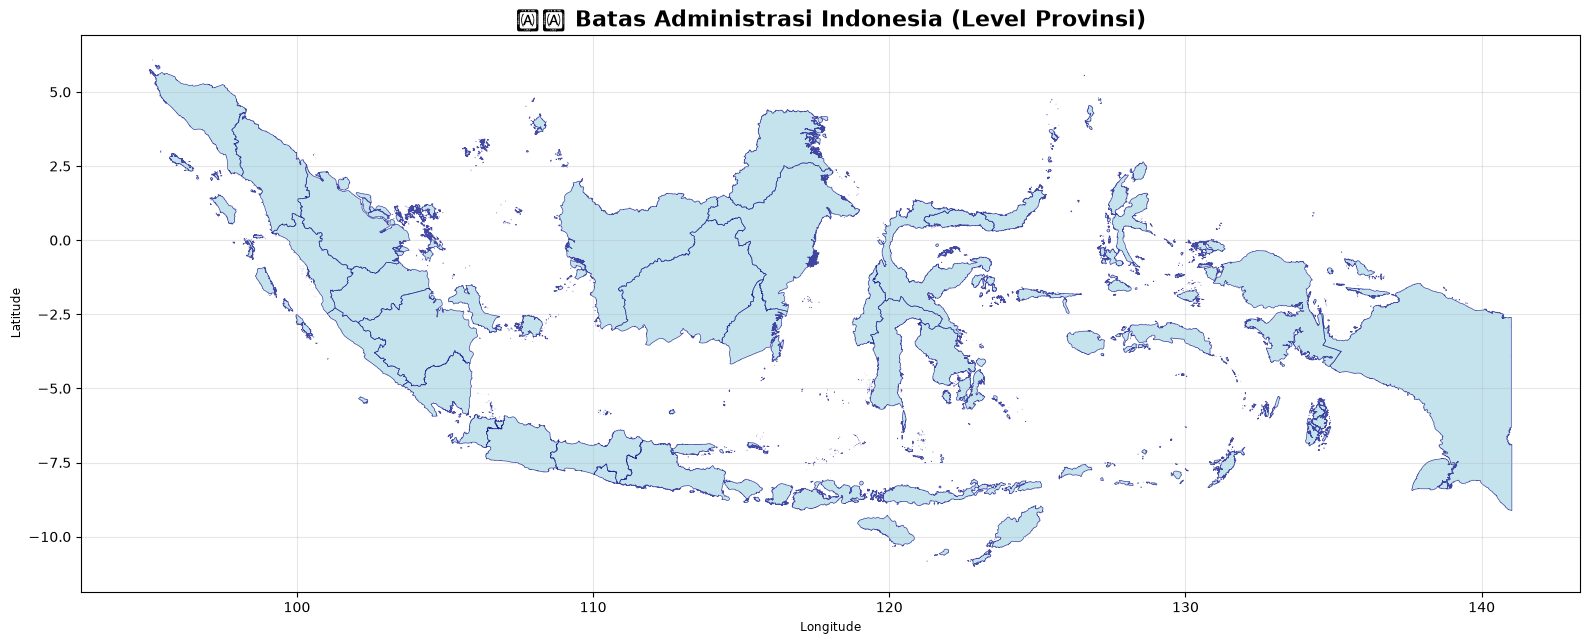

{"timestamp": "2026-10-03T18:13:17.899991+00:00", "level": "INFO", "module": "2208808229", "function": "<module>", "line": 23, "logger": "__main__", "message": "Peta Indonesia berhasil digambar", "extra": {"name": "__main__", "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\muham\\AppData\\Local\\Temp\\ipykernel_2284\\2208808229.py", "filename": "2208808229.py", "module": "2208808229", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 23, "funcName": "<module>", "created": 1791051197.8999908, "msecs": 899.0, "relativeCreated": 433431.7011833191, "thread": 24900, "threadName": "MainThread", "processName": "MainProcess", "process": 2284, "taskName": "Task-66", "n_provinces": 34}}


In [6]:
fig, ax = plt.subplots(figsize=(16, 10))

indonesia.plot(
    ax=ax,
    color="lightblue",
    edgecolor="navy",
    linewidth=0.5,
    alpha=0.7,
)

ax.set_title(
    "🇮🇩 Batas Administrasi Indonesia (Level Provinsi)",
    fontsize=16,
    fontweight="bold",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

log.info("Peta Indonesia berhasil digambar", extra={"n_provinces": len(indonesia)})

In [7]:
# Cek dulu kolom apa saja yang ada di nodes
print("Kolom di nodes:", list(nodes.columns))

# Deteksi otomatis kolom latitude & longitude
lat_candidates = [c for c in nodes.columns if c.lower() in ("lat", "latitude", "y")]
lon_candidates = [c for c in nodes.columns if c.lower() in ("lon", "lng", "longitude", "x")]

print(f"Kolom latitude  terdeteksi: {lat_candidates}")
print(f"Kolom longitude terdeteksi: {lon_candidates}")

# Jika nama kolom berbeda, sesuaikan di sini:
LAT_COL = lat_candidates[0] if lat_candidates else None
LON_COL = lon_candidates[0] if lon_candidates else None

if LAT_COL and LON_COL:
    # Konversi ke GeoDataFrame
    geometry = [Point(xy) for xy in zip(nodes[LON_COL], nodes[LAT_COL])]
    nodes_gdf = gpd.GeoDataFrame(nodes, geometry=geometry, crs="EPSG:4326")

    print(f"\n✅ Berhasil konversi {len(nodes_gdf)} node ke GeoDataFrame")
    print(f"📍 CRS: {nodes_gdf.crs}")
    print("\n🔍 Preview geometry:")
    print(nodes_gdf[[LAT_COL, LON_COL, "geometry"]].head())
else:
    print("\n⚠️  Kolom koordinat tidak terdeteksi otomatis.")
    print("    Silakan cek nama kolom di output di atas dan sesuaikan.")

Kolom di nodes: ['id', 'nama', 'provinsi', 'status', 'latitude', 'longitude']
Kolom latitude  terdeteksi: ['latitude']
Kolom longitude terdeteksi: ['longitude']

✅ Berhasil konversi 6 node ke GeoDataFrame
📍 CRS: EPSG:4326

🔍 Preview geometry:
   latitude  longitude                geometry
0    -7.141    107.806  POINT (107.806 -7.141)
1    -7.209    109.902  POINT (109.902 -7.209)
2     1.213    124.847   POINT (124.847 1.213)
3     2.034     99.132    POINT (99.132 2.034)
4    -4.306    103.897  POINT (103.897 -4.306)


C:\Users\muham\AppData\Local\Temp\ipykernel_2284\3648231929.py:49: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\muham\AppData\Local\Temp\ipykernel_2284\3648231929.py:50: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  plt.savefig(
C:\Users\muham\anaconda3\envs\geosdi\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


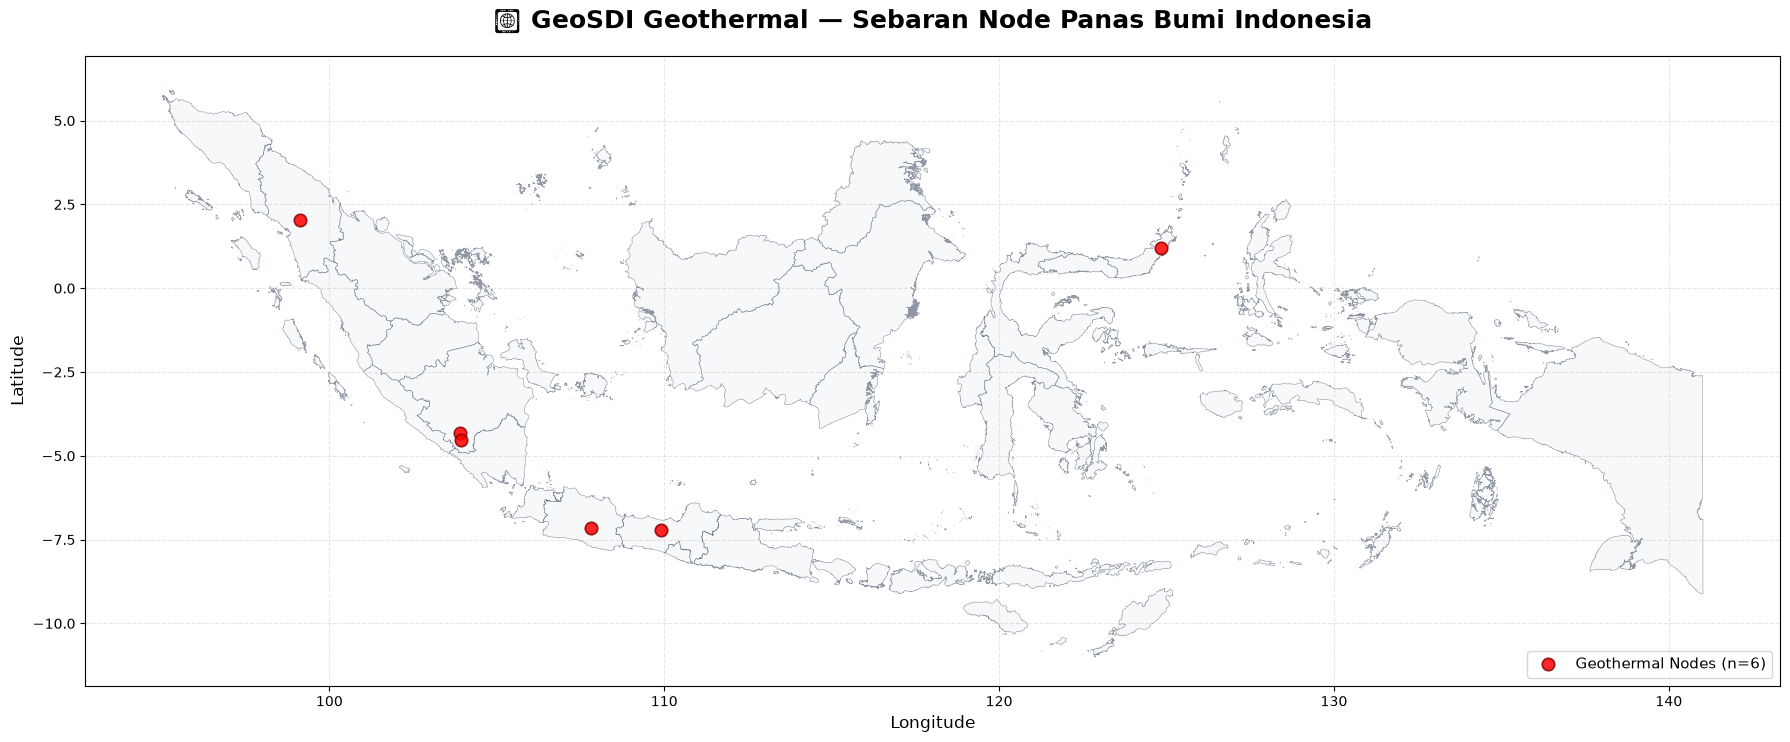

{"timestamp": "2026-10-03T18:13:35.237152+00:00", "level": "INFO", "module": "3648231929", "function": "<module>", "line": 57, "logger": "__main__", "message": "Peta node geothermal tersimpan", "extra": {"name": "__main__", "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\muham\\AppData\\Local\\Temp\\ipykernel_2284\\3648231929.py", "filename": "3648231929.py", "module": "3648231929", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 57, "funcName": "<module>", "created": 1791051215.2371523, "msecs": 237.0, "relativeCreated": 450768.8627243042, "thread": 24900, "threadName": "MainThread", "processName": "MainProcess", "process": 2284, "taskName": "Task-74", "n_nodes": 6, "lat_col": "latitude", "lon_col": "longitude"}}

💾 Peta tersimpan di: C:\geosdi\data\processed\peta_node_geothermal.png


In [8]:
if LAT_COL and LON_COL:
    fig, ax = plt.subplots(figsize=(18, 11))

    # Layer 1: Batas provinsi
    indonesia.plot(
        ax=ax,
        color="#f0f4f8",
        edgecolor="#4a5568",
        linewidth=0.4,
        alpha=0.6,
    )

    # Layer 2: Node geothermal
    nodes_gdf.plot(
        ax=ax,
        color="red",
        markersize=80,
        edgecolor="darkred",
        linewidth=1.2,
        alpha=0.85,
        label=f"Geothermal Nodes (n={len(nodes_gdf)})",
        zorder=5,
    )

    # Label tiap node
    for idx, row in nodes_gdf.iterrows():
        if "name" in row and pd.notna(row["name"]):
            ax.annotate(
                row["name"],
                xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
                color="darkred",
                fontweight="bold",
            )

    ax.set_title(
        "🌋 GeoSDI Geothermal — Sebaran Node Panas Bumi Indonesia",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.legend(loc="lower right", fontsize=11, frameon=True)
    ax.grid(True, alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.savefig(
        settings.data_processed_path / "peta_node_geothermal.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    log.info(
        "Peta node geothermal tersimpan",
        extra={"n_nodes": len(nodes_gdf), "lat_col": LAT_COL, "lon_col": LON_COL},
    )
    print(f"\n💾 Peta tersimpan di: {settings.data_processed_path / 'peta_node_geothermal.png'}")

📍 Kolom provinsi: provinsi

📊 Distribusi Node per Provinsi:
        province  count
Sumatera Selatan      2
      Jawa Barat      1
     Jawa Tengah      1
  Sulawesi Utara      1
  Sumatera Utara      1


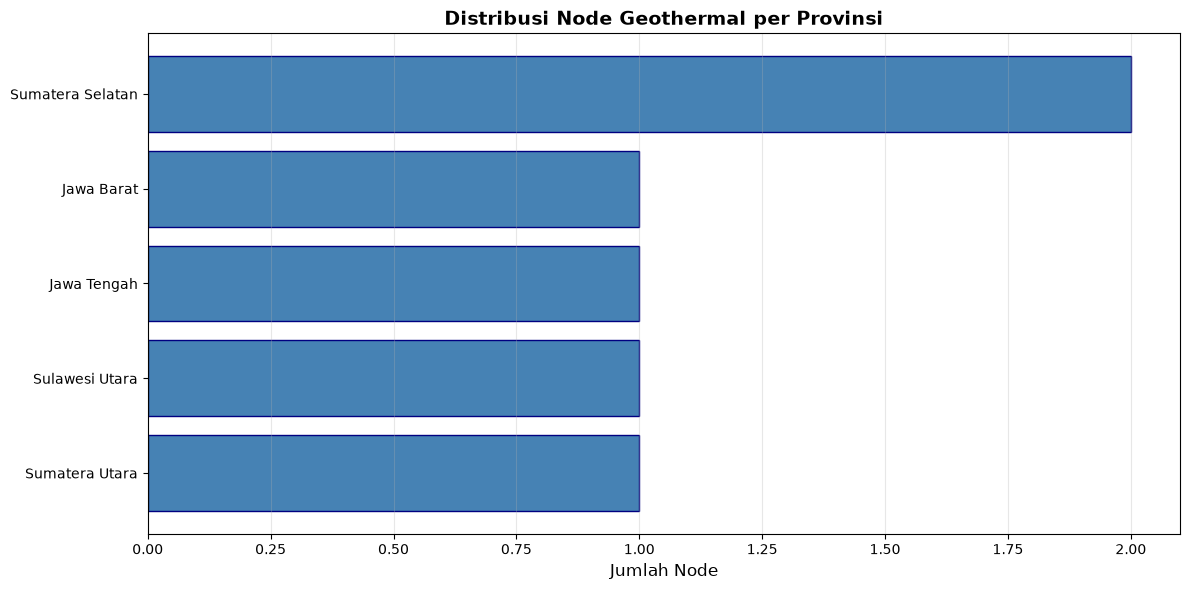

In [9]:
# Cek apakah ada kolom provinsi di data nodes
province_candidates = [
    c for c in nodes.columns
    if any(k in c.lower() for k in ("prov", "province", "wilayah", "region"))
]

if province_candidates:
    prov_col = province_candidates[0]
    print(f"📍 Kolom provinsi: {prov_col}")

    prov_stats = nodes[prov_col].value_counts().reset_index()
    prov_stats.columns = ["province", "count"]
    prov_stats = prov_stats.sort_values("count", ascending=False)

    print(f"\n📊 Distribusi Node per Provinsi:")
    print(prov_stats.to_string(index=False))

    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(
        prov_stats["province"],
        prov_stats["count"],
        color="steelblue",
        edgecolor="navy",
    )
    ax.set_xlabel("Jumlah Node", fontsize=12)
    ax.set_title("Distribusi Node Geothermal per Provinsi", fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Tidak ada kolom provinsi di data. Kita akan join dengan GeoJSON nanti.")

In [10]:
# Simpan data yang sudah bersih
if LAT_COL and LON_COL:
    output_path = settings.data_processed_path / "geothermal_nodes.geojson"
    nodes_gdf.to_file(output_path, driver="GeoJSON")

    log.info("Data bersih tersimpan", extra={"path": str(output_path)})
    print(f"\n✅ Data bersih tersimpan di:")
    print(f"   {output_path}")
    print(f"\n📊 Total node: {len(nodes_gdf)}")
    print(f"📊 Kolom: {list(nodes_gdf.columns)}")

{"timestamp": "2026-10-03T18:13:46.408659+00:00", "level": "INFO", "module": "raw", "function": "write", "line": 733, "logger": "pyogrio._io", "message": "Created 6 records", "extra": {"name": "pyogrio._io", "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\muham\\anaconda3\\envs\\geosdi\\Lib\\site-packages\\pyogrio\\raw.py", "filename": "raw.py", "module": "raw", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 733, "funcName": "write", "created": 1791051226.4086595, "msecs": 408.0, "relativeCreated": 461940.36984443665, "thread": 24900, "threadName": "MainThread", "processName": "MainProcess", "process": 2284, "taskName": "Task-82"}}
{"timestamp": "2026-10-03T18:13:46.409662+00:00", "level": "INFO", "module": "3900802510", "function": "<module>", "line": 6, "logger": "__main__", "message": "Data bersih tersimpan", "extra": {"name": "__main__", "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\muham\\AppData\\Local\\Temp\\ipykernel_2284\\3900802510